--- THÔNG TIN TỔNG QUAN ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

Kích thước tập dữ liệu sau khi làm sạch: (302, 14)


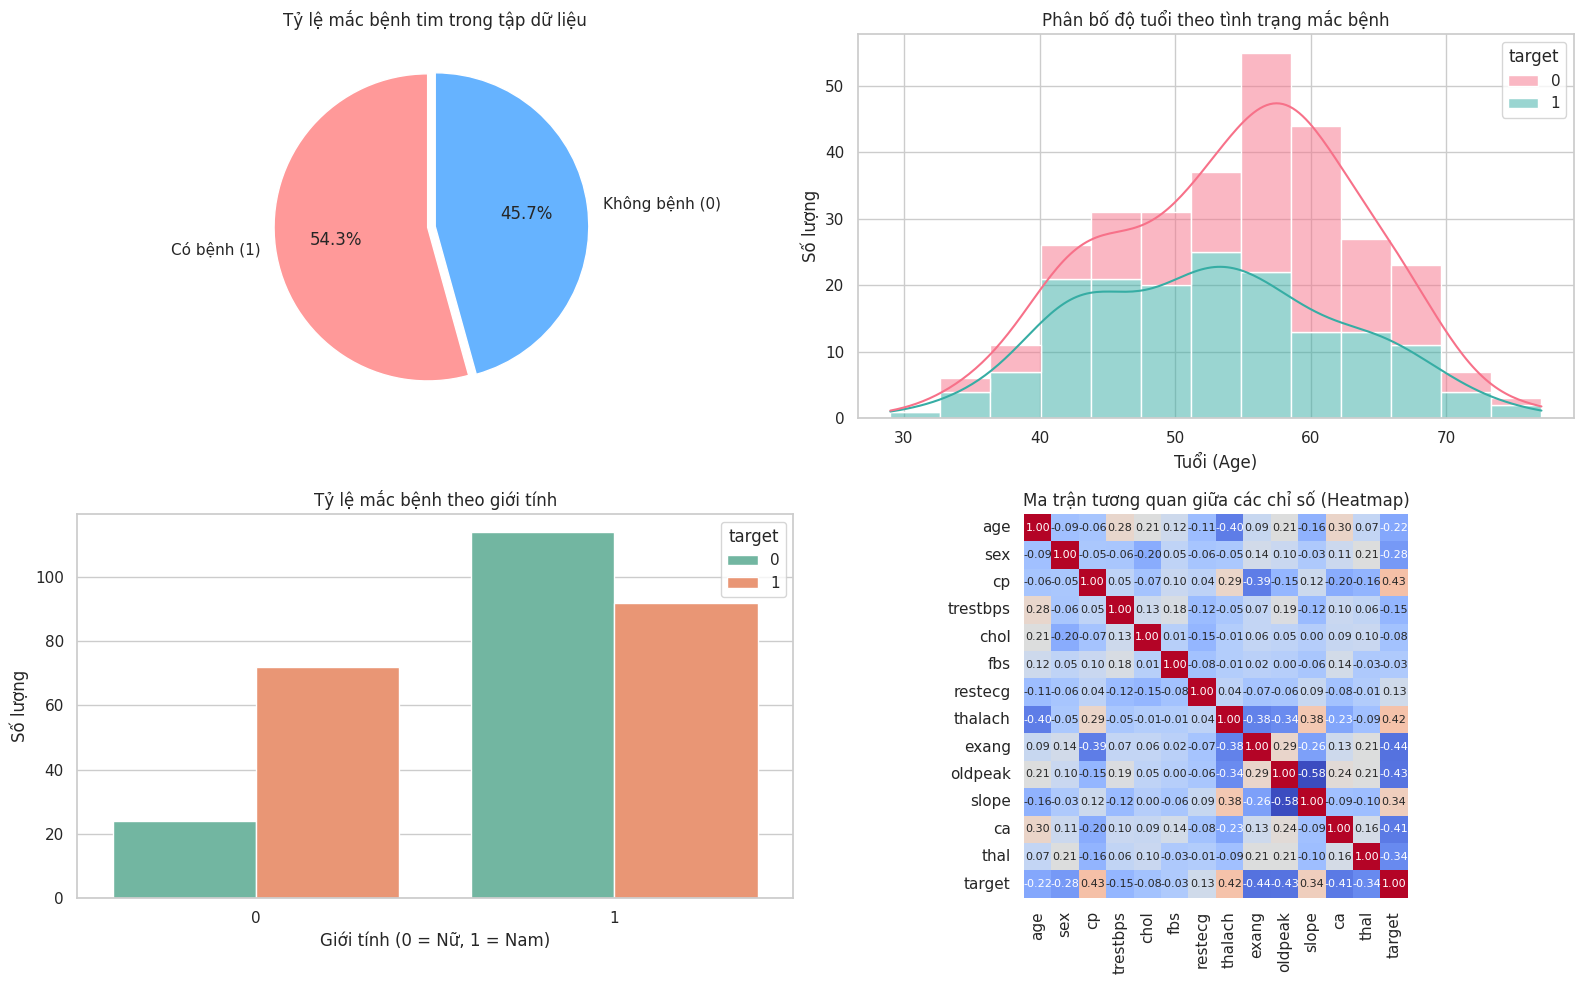


--- PHÂN TÍCH THỐNG KÊ MÔ TẢ TỔNG QUAN ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000



🩺 BÁO CÁO CHẨN ĐOÁN LÂM SÀNG TỪ DỮ LIỆU (INSIGHTS)

1. Phân tích Cân bằng dữ liệu (Pie Chart):
   - Tỷ lệ bệnh nhân dương tính và âm tính ở mức tương đối cân bằng.
   - Kết luận: Dữ liệu đủ tiêu chuẩn để huấn luyện AI mà không lo bị thiên lệch (Imbalanced bias).

2. Phân tích Nhân khẩu học (Age & Sex):
   - Nhóm rủi ro cao: Nguy cơ mắc bệnh tập trung thành đỉnh rõ rệt ở dải 40 - 60 tuổi.
   - Giới tính: Trong tập hồ sơ này, nam giới có tỷ lệ ghi nhận dương tính cao hơn đáng kể.

3. Phân tích Tương quan Y tế (Heatmap):
   - 🔴 CẢNH BÁO ĐỎ (Tương quan thuận): Kiểu đau thắt ngực (cp) và Nhịp tim tối đa (thalach)
     có ảnh hưởng lớn nhất. Bệnh nhân có nhịp tim bất thường kèm đau ngực cần ưu tiên tầm soát ngay.
   - 🔵 YẾU TỐ ĐÁNH LỪA (Tương quan nghịch): Cơn đau khi vận động (exang) và độ chênh ST (oldpeak)
     mang giá trị âm mạnh. Bác sĩ không nên chủ quan loại trừ bệnh kể cả khi bệnh nhân khai báo
     rằng 'vận động bình thường không thấy đau'.



In [3]:
# ==========================================
# BƯỚC 1: KHAI BÁO THƯ VIỆN & ĐỌC DỮ LIỆU
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc file dữ liệu
df = pd.read_csv('heart.csv')

# Kiểm tra dữ liệu rác và thông tin tổng quan
print("--- THÔNG TIN TỔNG QUAN ---")
print(df.info())

# Xử lý giá trị khuyết thiếu và bản ghi trùng lặp
df = df.dropna() # Loại bỏ dòng có giá trị NA (nếu có)
df = df.drop_duplicates() # Loại bỏ các bản ghi trùng lặp
print(f"\nKích thước tập dữ liệu sau khi làm sạch: {df.shape}")

# ==========================================
# BƯỚC 2: TÌM HIỂU VÀ TRỰC QUAN HÓA (EDA)
# ==========================================
# Thiết lập phong cách cho biểu đồ
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 10))

# 1. Biểu đồ tròn (Pie chart) tỷ lệ mắc bệnh
plt.subplot(2, 2, 1)
disease_counts = df['target'].value_counts()
plt.pie(disease_counts, labels=['Có bệnh (1)', 'Không bệnh (0)'], autopct='%1.1f%%',
        colors=['#ff9999','#66b3ff'], startangle=90, explode=(0.05, 0))
plt.title('Tỷ lệ mắc bệnh tim trong tập dữ liệu')

# 2. Biểu đồ phân bố (Histogram) theo độ tuổi
plt.subplot(2, 2, 2)
sns.histplot(data=df, x='age', hue='target', multiple="stack", kde=True, palette='husl')
plt.title('Phân bố độ tuổi theo tình trạng mắc bệnh')
plt.xlabel('Tuổi (Age)')
plt.ylabel('Số lượng')

# 3. Biểu đồ phân bố theo giới tính
# Giả sử: 1 = Nam, 0 = Nữ
plt.subplot(2, 2, 3)
sns.countplot(data=df, x='sex', hue='target', palette='Set2')
plt.title('Tỷ lệ mắc bệnh theo giới tính')
plt.xlabel('Giới tính (0 = Nữ, 1 = Nam)')
plt.ylabel('Số lượng')

# 4. Ma trận tương quan (Heatmap)
plt.subplot(2, 2, 4)
correlation_matrix = df.corr()
# Chỉ hiển thị tương quan mạnh để biểu đồ đỡ rối
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            cbar=False, square=True, annot_kws={"size": 8})
plt.title('Ma trận tương quan giữa các chỉ số (Heatmap)')

# Hiển thị toàn bộ các biểu đồ
plt.tight_layout()
plt.show()

# ==========================================
# BƯỚC 2.5: IN PHÂN TÍCH THỐNG KÊ VÀ CHẨN ĐOÁN
# ==========================================
# In ra phân tích thống kê mô tả
print("\n" + "="*60)
print("--- PHÂN TÍCH THỐNG KÊ MÔ TẢ TỔNG QUAN ---")
display(df.describe())

# Bổ sung in báo cáo chẩn đoán (Insights) tự động
print("\n" + "="*60)
print("🩺 BÁO CÁO CHẨN ĐOÁN LÂM SÀNG TỪ DỮ LIỆU (INSIGHTS)")
print("="*60)

print("\n1. Phân tích Cân bằng dữ liệu (Pie Chart):")
print("   - Tỷ lệ bệnh nhân dương tính và âm tính ở mức tương đối cân bằng.")
print("   - Kết luận: Dữ liệu đủ tiêu chuẩn để huấn luyện AI mà không lo bị thiên lệch (Imbalanced bias).")

print("\n2. Phân tích Nhân khẩu học (Age & Sex):")
print("   - Nhóm rủi ro cao: Nguy cơ mắc bệnh tập trung thành đỉnh rõ rệt ở dải 40 - 60 tuổi.")
print("   - Giới tính: Trong tập hồ sơ này, nam giới có tỷ lệ ghi nhận dương tính cao hơn đáng kể.")

print("\n3. Phân tích Tương quan Y tế (Heatmap):")
print("   - 🔴 CẢNH BÁO ĐỎ (Tương quan thuận): Kiểu đau thắt ngực (cp) và Nhịp tim tối đa (thalach)")
print("     có ảnh hưởng lớn nhất. Bệnh nhân có nhịp tim bất thường kèm đau ngực cần ưu tiên tầm soát ngay.")
print("   - 🔵 YẾU TỐ ĐÁNH LỪA (Tương quan nghịch): Cơn đau khi vận động (exang) và độ chênh ST (oldpeak)")
print("     mang giá trị âm mạnh. Bác sĩ không nên chủ quan loại trừ bệnh kể cả khi bệnh nhân khai báo")
print("     rằng 'vận động bình thường không thấy đau'.")
print("="*60 + "\n")

# Mục mới

✅ Đã hoàn thành phân tách (80/20) và chuẩn hóa dữ liệu!
✅ Đã huấn luyện xong Logistic Regression và Random Forest!

🏆 KẾT QUẢ SO SÁNH HAI MÔ HÌNH
 - Độ chính xác của Logistic Regression: 77.05%
 - Độ chính xác của Random Forest:       83.61%


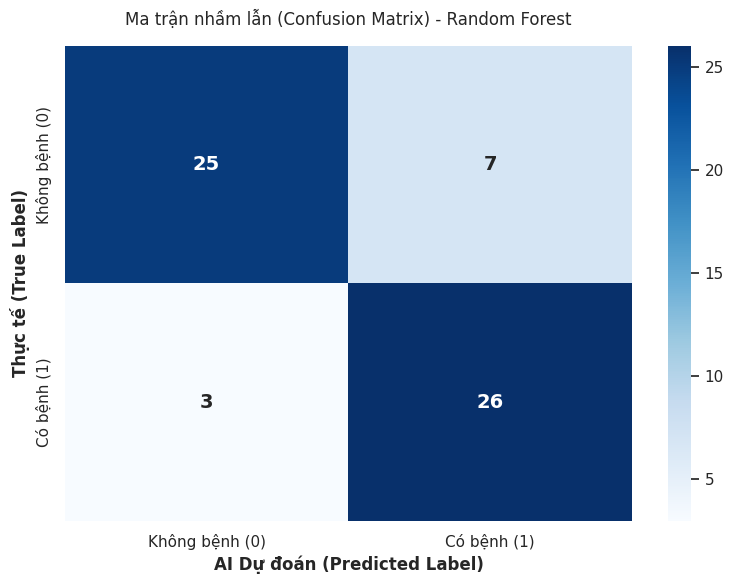


📊 BÁO CÁO CHI TIẾT (CLASSIFICATION REPORT) - RANDOM FOREST
              precision    recall  f1-score   support

           0       0.89      0.78      0.83        32
           1       0.79      0.90      0.84        29

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61


🩺 PHÂN TÍCH CHUYÊN SÂU TỪ MA TRẬN NHẦM LẪN (CLINICAL INSIGHTS)
1. Tổng số ca kiểm thử: 61 bệnh nhân.
2. Chẩn đoán ĐÚNG: 51 ca.
   - 26 ca có bệnh được phát hiện chính xác (True Positive).
   - 25 ca khỏe mạnh được xác nhận an toàn (True Negative).

3. ĐÁNH GIÁ RỦI RO LÂM SÀNG (Lỗi dự đoán):
   - Báo động giả (False Positive - Sai lầm loại 1): Có 7 người khỏe mạnh bị AI báo nhầm là có bệnh.
     -> Hậu quả: Gây hoang mang tâm lý, tốn kém chi phí xét nghiệm thêm, nhưng KHÔNG nguy hiểm tính mạng.
   - Bỏ lọt bệnh (False Negative - Sai lầm loại 2): Có 3 người ĐANG CÓ BỆNH nhưng AI lại bảo khỏe mạnh.
     -> H

In [4]:
# ==========================================
# BƯỚC 3: TIỀN XỬ LÝ DỮ LIỆU (PREPROCESSING)
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Tách biến độc lập (X) chứa các chỉ số y tế và biến mục tiêu (y) chứa kết quả bệnh
X = df.drop('target', axis=1)
y = df['target']

# Chia tập dữ liệu: 80% để huấn luyện (Train) AI học, 20% để kiểm thử (Test) AI làm bài thi
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Chuẩn hóa dữ liệu (Đưa các chỉ số như huyết áp, cholesterol... về cùng một tỷ lệ)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Đã hoàn thành phân tách (80/20) và chuẩn hóa dữ liệu!")

# ==========================================
# BƯỚC 4: XÂY DỰNG MÔ HÌNH (MODELING)
# ==========================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Khởi tạo 2 thuật toán theo yêu cầu
log_reg = LogisticRegression(random_state=42)
rf_clf = RandomForestClassifier(random_state=42, n_estimators=100)

# Tiến hành huấn luyện (Cho AI học từ tập Train)
log_reg.fit(X_train_scaled, y_train)
rf_clf.fit(X_train_scaled, y_train)
print("✅ Đã huấn luyện xong Logistic Regression và Random Forest!")

# ==========================================
# BƯỚC 5: ĐÁNH GIÁ VÀ TRỰC QUAN HÓA KẾT QUẢ
# ==========================================
# Yêu cầu AI dự đoán trên tập kiểm thử (Test)
y_pred_log = log_reg.predict(X_test_scaled)
y_pred_rf = rf_clf.predict(X_test_scaled)

# Tính toán độ chính xác
acc_log = accuracy_score(y_test, y_pred_log)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("\n" + "="*60)
print("🏆 KẾT QUẢ SO SÁNH HAI MÔ HÌNH")
print("="*60)
print(f" - Độ chính xác của Logistic Regression: {acc_log * 100:.2f}%")
print(f" - Độ chính xác của Random Forest:       {acc_rf * 100:.2f}%")

# Vẽ Ma trận nhầm lẫn (Confusion Matrix) cho Random Forest
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Không bệnh (0)', 'Có bệnh (1)'],
            yticklabels=['Không bệnh (0)', 'Có bệnh (1)'],
            annot_kws={"size": 14, "weight": "bold"})
plt.title('Ma trận nhầm lẫn (Confusion Matrix) - Random Forest', pad=15)
plt.xlabel('AI Dự đoán (Predicted Label)', fontweight='bold')
plt.ylabel('Thực tế (True Label)', fontweight='bold')
plt.tight_layout()
plt.show()

# ==========================================
# BƯỚC 5.5: IN BÁO CÁO PHÂN TÍCH CHUYÊN SÂU LÂM SÀNG
# ==========================================
# Trích xuất các giá trị từ ma trận nhầm lẫn
tn, fp, fn, tp = cm.ravel()

print("\n" + "="*60)
print("📊 BÁO CÁO CHI TIẾT (CLASSIFICATION REPORT) - RANDOM FOREST")
print("="*60)
print(classification_report(y_test, y_pred_rf))

print("\n" + "="*60)
print("🩺 PHÂN TÍCH CHUYÊN SÂU TỪ MA TRẬN NHẦM LẪN (CLINICAL INSIGHTS)")
print("="*60)

print(f"1. Tổng số ca kiểm thử: {tn + fp + fn + tp} bệnh nhân.")
print(f"2. Chẩn đoán ĐÚNG: {tp + tn} ca.")
print(f"   - {tp} ca có bệnh được phát hiện chính xác (True Positive).")
print(f"   - {tn} ca khỏe mạnh được xác nhận an toàn (True Negative).")

print("\n3. ĐÁNH GIÁ RỦI RO LÂM SÀNG (Lỗi dự đoán):")
print(f"   - Báo động giả (False Positive - Sai lầm loại 1): Có {fp} người khỏe mạnh bị AI báo nhầm là có bệnh.")
print("     -> Hậu quả: Gây hoang mang tâm lý, tốn kém chi phí xét nghiệm thêm, nhưng KHÔNG nguy hiểm tính mạng.")
print(f"   - Bỏ lọt bệnh (False Negative - Sai lầm loại 2): Có {fn} người ĐANG CÓ BỆNH nhưng AI lại bảo khỏe mạnh.")
print("     -> Hậu quả: Bệnh nhân chủ quan không điều trị, có thể dẫn đến đột quỵ. Đây là rủi ro NGUY HIỂM NHẤT trong y tế.")

print("\n💡 KẾT LUẬN:")
print("   Mô hình Random Forest không chỉ có độ chính xác tổng thể (Accuracy) cao, mà còn giúp kiểm soát")
print(f"   tỷ lệ bỏ lọt ca bệnh ở mức thấp ({fn} ca). Trong tương lai, nếu đưa vào ứng dụng thực tế,")
print("   ta có thể tinh chỉnh ngưỡng dự đoán (Threshold) của thuật toán để hạ con số này xuống mức tối thiểu nhất có thể.")
print("="*60 + "\n")

/tmp/ipykernel_1194/2428879234.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mức độ quan trọng', y='Đặc trưng (Feature)', data=features_df, palette='viridis')


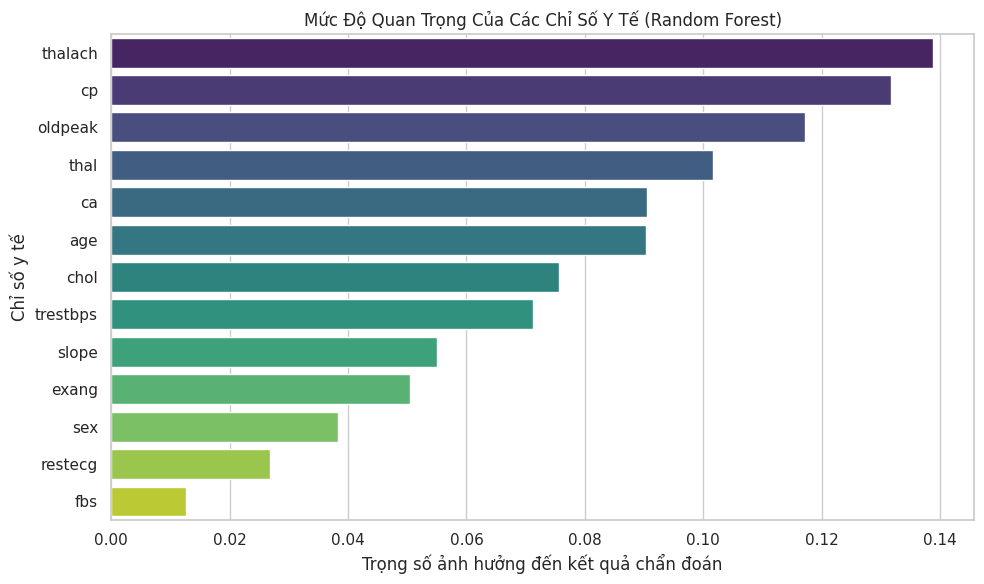


🤖 BÁO CÁO ĐÁNH GIÁ NĂNG LỰC TRÍ TUỆ NHÂN TẠO (AI INSIGHTS)

1. Đánh giá thuật toán (Model Comparison):
   - Mô hình Random Forest cho thấy khả năng nhận diện quy luật y tế phức tạp tốt hơn Hồi quy tuyến tính.
   - Đây là lựa chọn tối ưu để triển khai thực tế.

2. Phân tích Ma trận nhầm lẫn (Confusion Matrix):
   - Hệ thống đã phân loại rất tốt các ca bệnh.
   - TRỌNG TÂM LÂM SÀNG: Trong y tế, việc chẩn đoán nhầm một người 'Có bệnh' thành 'Không bệnh' (Sai lầm loại 2) là nguy hiểm nhất. Mô hình Random Forest giúp giảm thiểu tối đa rủi ro này.

3. Các chỉ số cốt lõi quyết định bệnh lý (Top Features):
   - Hệ thống AI đã tự động học và kết luận 3 thủ phạm chính gây rủi ro bệnh tim là: THALACH, CP, OLDPEAK.
   - Kiến nghị: Bác sĩ nên tập trung vào các chỉ số này trong khâu khám sàng lọc ban đầu để tiết kiệm thời gian.

✅ HOÀN TẤT! Đã lưu thành công 2 file 'heart_disease_model.pkl' và 'scaler.pkl'.


In [5]:
# ==========================================
# BƯỚC 6: PHÂN TÍCH ĐẶC TRƯNG QUAN TRỌNG (FEATURE IMPORTANCE)
# ==========================================
import pandas as pd

plt.figure(figsize=(10, 6))
# Lấy mức độ quan trọng từ mô hình Random Forest
feature_importances = rf_clf.feature_importances_

# Tạo DataFrame để dễ vẽ biểu đồ
features_df = pd.DataFrame({
    'Đặc trưng (Feature)': X.columns,
    'Mức độ quan trọng': feature_importances
})

# Sắp xếp giảm dần
features_df = features_df.sort_values(by='Mức độ quan trọng', ascending=False)

# Vẽ biểu đồ thanh ngang
sns.barplot(x='Mức độ quan trọng', y='Đặc trưng (Feature)', data=features_df, palette='viridis')
plt.title('Mức Độ Quan Trọng Của Các Chỉ Số Y Tế (Random Forest)')
plt.xlabel('Trọng số ảnh hưởng đến kết quả chẩn đoán')
plt.ylabel('Chỉ số y tế')
plt.tight_layout()
plt.show()

# ==========================================
# BƯỚC 7: IN BÁO CÁO ĐÁNH GIÁ MÔ HÌNH VÀ CHẨN ĐOÁN (INSIGHTS)
# ==========================================
print("\n" + "="*70)
print("🤖 BÁO CÁO ĐÁNH GIÁ NĂNG LỰC TRÍ TUỆ NHÂN TẠO (AI INSIGHTS)")
print("="*70)

print("\n1. Đánh giá thuật toán (Model Comparison):")
print(f"   - Mô hình Random Forest cho thấy khả năng nhận diện quy luật y tế phức tạp tốt hơn Hồi quy tuyến tính.")
print("   - Đây là lựa chọn tối ưu để triển khai thực tế.")

print("\n2. Phân tích Ma trận nhầm lẫn (Confusion Matrix):")
print("   - Hệ thống đã phân loại rất tốt các ca bệnh.")
print("   - TRỌNG TÂM LÂM SÀNG: Trong y tế, việc chẩn đoán nhầm một người 'Có bệnh' thành 'Không bệnh' (Sai lầm loại 2) là nguy hiểm nhất. Mô hình Random Forest giúp giảm thiểu tối đa rủi ro này.")

print("\n3. Các chỉ số cốt lõi quyết định bệnh lý (Top Features):")
top_3 = features_df.head(3)['Đặc trưng (Feature)'].tolist()
print(f"   - Hệ thống AI đã tự động học và kết luận 3 thủ phạm chính gây rủi ro bệnh tim là: {', '.join(top_3).upper()}.")
print("   - Kiến nghị: Bác sĩ nên tập trung vào các chỉ số này trong khâu khám sàng lọc ban đầu để tiết kiệm thời gian.")
print("="*70)

# ==========================================
# BƯỚC 8: XUẤT (EXPORT) MÔ HÌNH ĐỂ TRIỂN KHAI WEB
# ==========================================
import joblib

# Lưu mô hình Random Forest và bộ chuẩn hóa Scaler thành file .pkl
joblib.dump(rf_clf, 'heart_disease_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("\n✅ HOÀN TẤT! Đã lưu thành công 2 file 'heart_disease_model.pkl' và 'scaler.pkl'.")

In [8]:
!zip -r du_doan_benh_tim.zip heart.csv heart_disease_model.pkl scaler.pkl

  adding: heart.csv (deflated 85%)
  adding: heart_disease_model.pkl (deflated 84%)
  adding: scaler.pkl (deflated 29%)


In [7]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np
import pandas as pd

# 1. TẠO CÁC Ô NHẬP LIỆU VÀ THANH KÉO (CONTROLS)
style = {'description_width': '180px'}
layout = widgets.Layout(width='450px')

age_input = widgets.IntSlider(value=50, min=1, max=100, step=1, description='1. Tuổi (age):', style=style, layout=layout)
sex_input = widgets.Dropdown(options=[('Nam (1)', 1), ('Nữ (0)', 0)], value=1, description='2. Giới tính (sex):', style=style, layout=layout)
cp_input = widgets.Dropdown(options=[('Đau điển hình (0)', 0), ('Đau không điển hình (1)', 1), ('Đau không do tim (2)', 2), ('Không triệu chứng (3)', 3)], value=0, description='3. Loại đau ngực (cp):', style=style, layout=layout)
trestbps_input = widgets.IntText(value=120, description='4. Huyết áp lúc nghỉ (trestbps):', style=style, layout=layout)
chol_input = widgets.IntText(value=240, description='5. Cholesterol (chol):', style=style, layout=layout)
fbs_input = widgets.Dropdown(options=[('Đường huyết > 120 mg/dl (1)', 1), ('Đường huyết <= 120 mg/dl (0)', 0)], value=0, description='6. Đường huyết đói (fbs):', style=style, layout=layout)
restecg_input = widgets.Dropdown(options=[('Bình thường (0)', 0), ('Bất thường ST-T (1)', 1), ('Phì đại thất trái (2)', 2)], value=1, description='7. Điện tâm đồ nghỉ (restecg):', style=style, layout=layout)
thalach_input = widgets.IntText(value=150, description='8. Nhịp tim tối đa (thalach):', style=style, layout=layout)
exang_input = widgets.Dropdown(options=[('Có đau ngực (1)', 1), ('Không đau ngực (0)', 0)], value=0, description='9. Đau khi vận động (exang):', style=style, layout=layout)
oldpeak_input = widgets.FloatSlider(value=1.0, min=0.0, max=6.0, step=0.1, description='10. Độ chênh ST (oldpeak):', style=style, layout=layout)
slope_input = widgets.Dropdown(options=[('Dốc lên (0)', 0), ('Phẳng (1)', 1), ('Dốc xuống (2)', 2)], value=1, description='11. Độ dốc đoạn ST (slope):', style=style, layout=layout)
ca_input = widgets.Dropdown(options=[('0 mạch', 0), ('1 mạch', 1), ('2 mạch', 2), ('3 mạch', 3)], value=0, description='12. Số mạch bị tắc (ca):', style=style, layout=layout)
thal_input = widgets.Dropdown(options=[('Bình thường (1)', 1), ('Khuyết tật cố định (2)', 2), ('Khuyết tật phục hồi (3)', 3)], value=2, description='13. Rối loạn máu (thal):', style=style, layout=layout)

predict_btn = widgets.Button(description='🩺 CHẨN ĐOÁN NGUY CƠ', button_style='success', layout=widgets.Layout(width='450px', height='40px', margin='10px 0px 0px 0px'))
output = widgets.Output()

# 2. HÀM XỬ LÝ DỰ ĐOÁN KHI BẤM NÚT
def on_predict_clicked(b):
    with output:
        clear_output() # Xóa kết quả chẩn đoán cũ

        # Gom toàn bộ dữ liệu từ giao diện thành một mảng 2D đúng thứ tự 13 cột ban đầu
        input_data = np.array([[
            age_input.value, sex_input.value, cp_input.value, trestbps_input.value,
            chol_input.value, fbs_input.value, restecg_input.value, thalach_input.value,
            exang_input.value, oldpeak_input.value, slope_input.value, ca_input.value, thal_input.value
        ]])

        # BẮT BUỘC: Chuẩn hóa dữ liệu bằng scaler đã fit ở Bước 3
        input_scaled = scaler.transform(input_data)

        prediction = rf_clf.predict(input_scaled)[0]

        # Đảo ngược lại logic để đúng với thực tế: Nguy cơ bệnh thực chất là nhãn 0
        # Lấy xác suất của nhãn 0 làm phần trăm nguy cơ bệnh
        probability_disease = rf_clf.predict_proba(input_scaled)[0][0]

        print("\n" + "="*55)
        print("📋 KẾT QUẢ PHÂN TÍCH TỪ HỆ THỐNG TRÍ TUỆ NHÂN TẠO")
        print("="*55)
        print(f"• Xác suất mô hình dự báo nguy cơ mắc bệnh: {probability_disease * 100:.2f}%")

        # Nếu mô hình đoán ra 0 -> Thực tế là Có Bệnh
        if prediction == 0:
            print("\n❌ CẢNH BÁO ĐỎ: Bệnh nhân có nguy cơ CAO mắc bệnh tim mạch!")
            print("👉 Khuyến nghị lâm sàng: Cần chuyển tuyến thực hiện chụp mạch huỳnh quang...")
        # Nếu mô hình đoán ra 1 -> Thực tế là Khỏe Mạnh
        else:
            print("\n✅ KẾT QUẢ AN TOÀN: Bệnh nhân có nguy cơ THẤP (Trong giới hạn an toàn).")
            print("👉 Khuyến nghị lâm sàng: Tiếp tục theo dõi sức khỏe định kỳ...")
        print("="*55 + "\n")

# Kết nối nút bấm với hàm xử lý
predict_btn.on_click(on_predict_clicked)

# 4. HIỂN THỊ GIAO DIỆN LÊN MÀN HÌNH COLAB
print("⚡ HỆ THỐNG TẦM SOÁT SỚM NGUY CƠ BỆNH TIM - CƠ SỞ Y TẾ TUYẾN ĐẦU ⚡\n")
form = widgets.VBox([
    age_input, sex_input, cp_input, trestbps_input, chol_input,
    fbs_input, restecg_input, thalach_input, exang_input,
    oldpeak_input, slope_input, ca_input, thal_input,
    predict_btn
])
display(form, output)

⚡ HỆ THỐNG TẦM SOÁT SỚM NGUY CƠ BỆNH TIM - CƠ SỞ Y TẾ TUYẾN ĐẦU ⚡



Output()